In [8]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

In [9]:
df = pd.read_csv("dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [10]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# ✅ move this OUTSIDE
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()

    # ✅ fast filtering
    words = [w for w in words if w not in stop_words]

    return " ".join(words)

# ⚡ apply
df['cleaned'] = df['review'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned'])
y = df['sentiment']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

# FAST SVM
svm = LinearSVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

# LIGHT Random Forest
rf = RandomForestClassifier(n_estimators=50)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score, classification_report

# Evaluate Naive Bayes
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

# Evaluate SVM
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

# Evaluate Random Forest
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Naive Bayes Accuracy: 0.8525
Naive Bayes Classification Report:
              precision    recall  f1-score   support

    negative       0.86      0.85      0.85      5071
    positive       0.85      0.86      0.85      4929

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

SVM Accuracy: 0.8813
SVM Classification Report:
              precision    recall  f1-score   support

    negative       0.89      0.88      0.88      5071
    positive       0.87      0.89      0.88      4929

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

Random Forest Accuracy: 0.8405
Random Forest Classification Report:
              precision    recall  f1-score   support

    negative       0.83      0.86      0.85      5071
    positive       0.85      0.82      0.84      4929

  

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_test, y_pred, name):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

evaluate(y_test, y_pred_nb, "Naive Bayes")
evaluate(y_test, y_pred_svm, "SVM")
evaluate(y_test, y_pred_rf, "Random Forest")


Naive Bayes
Accuracy: 0.8525
Precision: 0.8525780193120772
Recall: 0.8525
F1 Score: 0.8525072884531953

SVM
Accuracy: 0.8813
Precision: 0.8813863518443468
Recall: 0.8813
F1 Score: 0.8813059412872589

Random Forest
Accuracy: 0.8405
Precision: 0.8407807186159513
Recall: 0.8405
F1 Score: 0.8404221196137962


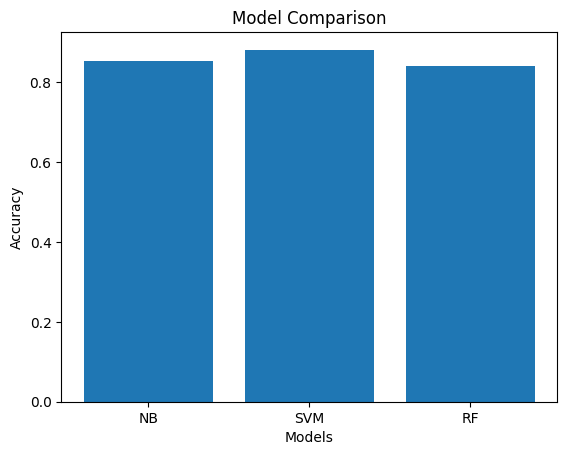

In [18]:
import matplotlib.pyplot as plt

models = ['NB', 'SVM', 'RF']
accuracy = [
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

In [19]:
sample = ["this movie is amazing"]

sample_clean = [clean_text(sample[0])]
sample_vec = vectorizer.transform(sample_clean)

print("Prediction:", nb.predict(sample_vec))

Prediction: ['positive']


In [20]:
import pickle

pickle.dump(nb, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))
